# Bluetooth LE and BR/EDR EDR Scratch Pad

Explore uncoded LE 1M/2M GFSK and payload-only BR/EDR EDR2M/EDR3M differential PSK. These aligned baseband models are not complete Bluetooth packets. The EDR cells correlate their differential symbol states with the Keysight 89600 Digital Demod result.

The LE receiver uses a frequency discriminator; QAM-style EVM does not apply.

## 1. Configure the LE PHY

In [1]:
import sys
from pathlib import Path

project_root = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if not (project_root / "wireless_phy.py").is_file():
    project_root = project_root / "nr5g_demod"
if not (project_root / "wireless_phy.py").is_file():
    raise FileNotFoundError("Open the nr5g_demod project folder before running this script")
project_root = project_root.resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np

from wireless_phy import BluetoothConfig, generate_bluetooth_waveform
from wireless_phy import demodulate_bluetooth, plot_wireless_result

bluetooth_cfg = BluetoothConfig(
    phy="LE2M",
    n_bits=128,
    samples_per_symbol=8,
    snr_db=20.0,
    seed=42,
)

print(f"PHY: {bluetooth_cfg.phy}")
print(f"Symbol rate: {bluetooth_cfg.symbol_rate_hz / 1e6:.1f} Msymbol/s")
print(f"Sample rate: {bluetooth_cfg.sample_rate_hz / 1e6:.1f} Msps")
print(f"Frequency deviation: +/-{bluetooth_cfg.frequency_deviation_hz / 1e3:.1f} kHz")
print(f"Samples per bit: {bluetooth_cfg.samples_per_symbol}")

PHY: LE2M
Symbol rate: 2.0 Msymbol/s
Sample rate: 16.0 Msps
Frequency deviation: +/-500.0 kHz
Samples per bit: 8


## 2. Generate the Gaussian-filtered continuous-phase waveform

In [2]:
bluetooth_waveform = generate_bluetooth_waveform(bluetooth_cfg)
print(f"Transmit bits: {bluetooth_waveform['tx_bits'].size}")
print(f"IQ samples: {bluetooth_waveform['time_signal'].size}")
print(f"Clean envelope range: {np.abs(bluetooth_waveform['time_signal_clean']).min():.6f} .. "
      f"{np.abs(bluetooth_waveform['time_signal_clean']).max():.6f}")
print("First 32 bits:", bluetooth_waveform["tx_bits"][:32].tolist())

Transmit bits: 128
IQ samples: 1025
Clean envelope range: 1.000000 .. 1.000000
First 32 bits: [1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1]


## 3. Discriminate frequency and integrate one decision per bit

In [9]:
bluetooth_result = demodulate_bluetooth(
    bluetooth_waveform["time_signal"],
    bluetooth_cfg,
    tx_bits=bluetooth_waveform["tx_bits"],
)

frequency_hz = bluetooth_result.diagnostics["frequency_hz"]
decision_metric = bluetooth_result.diagnostics["decision_metric"]
print(f"BER: {bluetooth_result.ber:.3e}")
print(f"QAM-style EVM: {bluetooth_result.evm_rms}")
print("First 16 frequency decisions (kHz):",
      np.round(frequency_hz[:16] / 1e3, 1).tolist())
print("First 16 normalized bit metrics:", np.round(decision_metric[:16], 3).tolist())

BER: 0.000e+00
QAM-style EVM: None
First 16 frequency decisions (kHz): [495.5, 291.7, 423.7, 505.2, 590.8, 194.0, 367.1, 228.0, -212.3, -341.1, -318.5, -168.8, -916.5, -70.2, -263.1, -44.2]
First 16 normalized bit metrics: [0.774, -0.584, 0.527, -0.63, 0.882, 0.782, -0.556, 0.73, 1.054, 0.979, 1.049, 0.75, -0.755, -1.07, -0.96, -0.998]


## 4. Check constant gain and phase invariance

In [10]:
gain_phase_signal = bluetooth_waveform["time_signal"] * 1.5 * np.exp(1.2j)
gain_phase_result = demodulate_bluetooth(
    gain_phase_signal,
    bluetooth_cfg,
    tx_bits=bluetooth_waveform["tx_bits"],
)
print(f"BER after constant gain and phase rotation: {gain_phase_result.ber:.3e}")
print("The discriminator uses adjacent-sample phase change, so constant phase cancels.")

BER after constant gain and phase rotation: 0.000e+00
The discriminator uses adjacent-sample phase change, so constant phase cancels.


## 5. Plot IQ, spectrum, discriminator output, and bit metrics

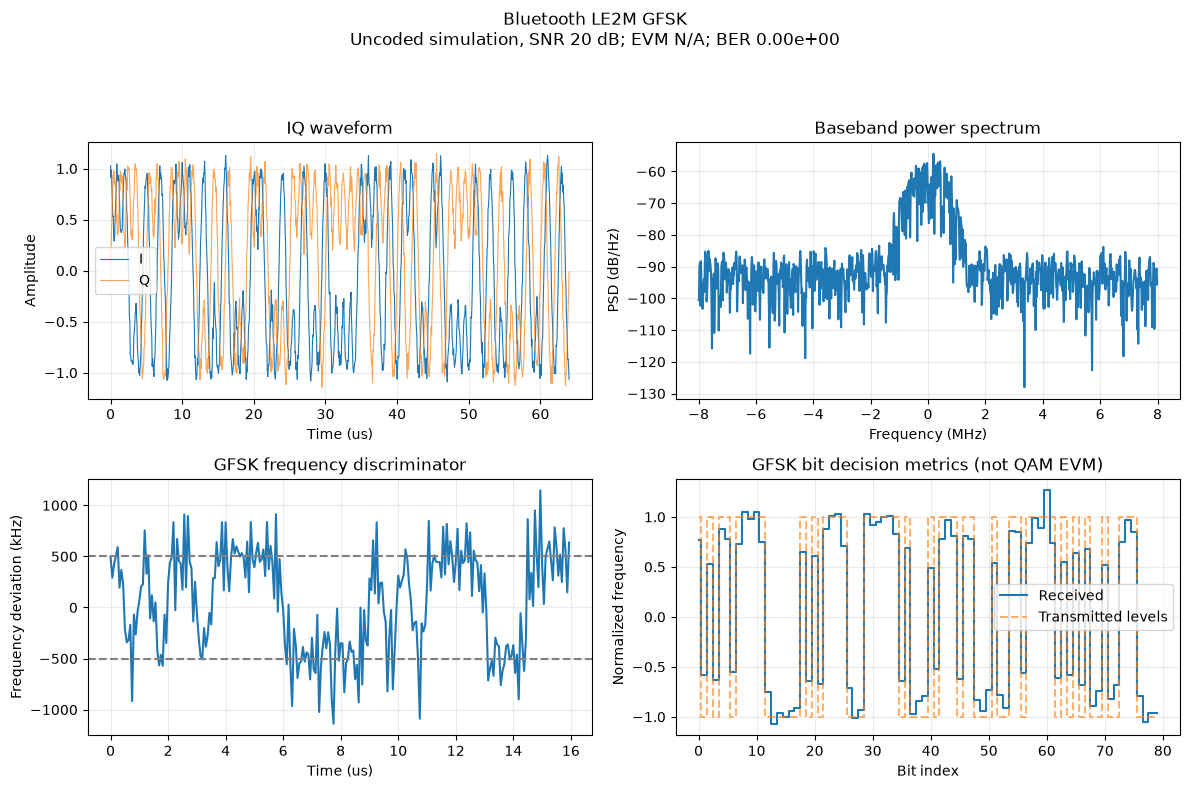

In [5]:
bluetooth_figure = plot_wireless_result(bluetooth_waveform, bluetooth_result)
plt.show()

## 6. BR/EDR EDR2M and EDR3M Payloads

These cells model the differential-PSK payload only, with a phase-reference symbol for aligned demodulation. They omit the complete packet structure, access code, header, guard, whitening, CRC, FEC, and preceding GFSK section.

In [7]:
import importlib
import wireless_phy
wireless_phy = importlib.reload(wireless_phy)
from wireless_phy import BluetoothEDRConfig, generate_bluetooth_edr_waveform
from wireless_phy import demodulate_bluetooth_edr

edr_runs = {}
for edr_phy in ("EDR2M", "EDR3M"):
    edr_cfg = BluetoothEDRConfig(phy=edr_phy, n_symbols=512, snr_db=None, seed=17)
    edr_waveform = generate_bluetooth_edr_waveform(edr_cfg)
    edr_result = demodulate_bluetooth_edr(
        edr_waveform["time_signal"], edr_cfg,
        tx_bits=edr_waveform["tx_bits"], tx_symbols=edr_waveform["tx_symbols"],
    )
    edr_runs[edr_phy] = (edr_cfg, edr_waveform, edr_result)
    print(f"{edr_phy}: local BER={edr_result.ber:.3e}, "
          f"differential-symbol EVM={edr_result.evm_rms:.3f}%")

EDR2M: local BER=0.000e+00, differential-symbol EVM=0.000%
EDR3M: local BER=0.000e+00, differential-symbol EVM=0.000%


## 7. Correlate EDR Payload States with Keysight 89600

Requires the VSA Digital Demod option. The VSA returns discrete `Syms/Errs1` state indices; correlation is performed on the matched payload symbols. The VSA status, including any `GapData` warning, is retained.

In [8]:
from compare import correlate_symbol_streams
from wireless_phy import bluetooth_edr_bits_from_state_indices
from wireless_phy import bluetooth_edr_symbols_from_state_indices
from vsa_89600 import run_vsa_edr_demod

for edr_phy, (edr_cfg, edr_waveform, edr_result) in edr_runs.items():
    vsa_edr_result = run_vsa_edr_demod(
        edr_waveform["time_signal"], edr_cfg, center_freq_hz=2.44e9, visible=True)
    vsa_symbols = bluetooth_edr_symbols_from_state_indices(
        vsa_edr_result.symbol_indices, edr_cfg)
    offset, correlation = correlate_symbol_streams(
        edr_result.rx_symbols, vsa_symbols.real, vsa_symbols.imag, max_lag=None)
    python_start = max(0, -offset)
    vsa_start = max(0, offset)
    matched = min(len(edr_result.rx_symbols) - python_start,
                  len(vsa_symbols) - vsa_start)
    python_states = edr_result.diagnostics["symbol_indices"][python_start:python_start + matched]
    vsa_states = vsa_edr_result.symbol_indices[vsa_start:vsa_start + matched]
    state_ber = np.mean(python_states != vsa_states)
    bits_per_symbol = edr_cfg.bits_per_symbol
    python_bits = edr_result.rx_bits[python_start * bits_per_symbol:
                                     (python_start + matched) * bits_per_symbol]
    vsa_bits = bluetooth_edr_bits_from_state_indices(vsa_states, edr_cfg)
    bit_ber = np.mean(python_bits != vsa_bits)
    print(f"{edr_phy} VSA status: {vsa_edr_result.measurement_status}")
    print(f"  matched symbols={matched}, offset={offset}, correlation={correlation:.9f}")
    print(f"  state BER={state_ber:.3e}, payload BER={bit_ber:.3e}")

EDR2M VSA status: MeasurementDone, GapData, Visible; Single sweep - paused
  matched symbols=299, offset=-63, correlation=1.000000000
  state BER=0.000e+00, payload BER=0.000e+00
EDR3M VSA status: MeasurementDone, GapData, Visible; Single sweep - paused
  matched symbols=299, offset=-63, correlation=1.000000000
  state BER=0.000e+00, payload BER=0.000e+00
